# Phase 2: Text-Dependent Speaker Verification — Kaggle
## TDNN + AAM-Softmax (ArcFace)

### Before running:
- Run Phase 1 notebook first (or attach its output dataset)
- Enable **GPU P100** in Accelerator settings
- If attaching Phase 1 output: Add Data → Your Datasets → phase1-output

In [1]:
!pip install -q librosa soundfile
print('Done.')

Done.


In [2]:
import os, glob, json, pickle, random
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import defaultdict
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from scipy.spatial.distance import cosine
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Safe device selection — test GPU with a dummy tensor first
def get_safe_device():
    if not torch.cuda.is_available():
        print('CUDA not available — using CPU')
        return torch.device('cpu')
    try:
        t = torch.zeros(1).cuda()
        _ = t + 1          # trigger kernel to verify it works
        print(f'GPU OK: {torch.cuda.get_device_name(0)}')
        return torch.device('cuda')
    except Exception as e:
        print(f'GPU failed ({e}) — falling back to CPU')
        return torch.device('cpu')

device = get_safe_device()

# ── Paths ──────────────────────────────────────────────────────────────────────
import glob as _glob

phase1_candidates = _glob.glob('/kaggle/input/**/phase1_summary.json', recursive=True)
if phase1_candidates:
    DATA_DIR = str(Path(phase1_candidates[0]).parent)
    print(f'Phase 1 data found: {DATA_DIR}')
else:
    DATA_DIR = '/kaggle/working/voice_auth/data'
    print(f'Using same-session data: {DATA_DIR}')

OUT_DIR     = '/kaggle/working/voice_auth_phase2'
RESULTS_DIR = f'{OUT_DIR}/results'
MODEL_DIR   = f'{OUT_DIR}/models'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,   exist_ok=True)

with open(f'{DATA_DIR}/phase1_summary.json') as f:
    cfg = json.load(f)

SAMPLE_RATE   = cfg['sample_rate']
SPEAKER_NAME  = 'abhiram'
EMBEDDING_DIM = 256
BATCH_SIZE    = 32
EPOCHS        = 80
LR            = 1e-3
INPUT_DIM     = 40
MAX_FRAMES    = 300

BASE_INPUT   = str(Path(DATA_DIR).parent)
GENUINE_DIR  = f'{BASE_INPUT}/data/processed/genuine'
IMPOSTOR_DIR = f'{BASE_INPUT}/data/processed/impostor'
SPOOF_DIR    = f'{BASE_INPUT}/data/processed/spoof'

print(f'Read  : {BASE_INPUT}')
print(f'Write : {OUT_DIR}')
print(f'Genuine files : {len(glob.glob(GENUINE_DIR+"/*.wav"))}')
print(f'Impostor files: {len(glob.glob(IMPOSTOR_DIR+"/*.wav"))}')


GPU OK: Tesla T4
Phase 1 data found: /kaggle/input/datasets/abhi2007798/voice-auth-phase1/voice_auth/data
Read  : /kaggle/input/datasets/abhi2007798/voice-auth-phase1/voice_auth
Write : /kaggle/working/voice_auth_phase2
Genuine files : 400
Impostor files: 400


In [3]:
import os, glob, json, pickle, random
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import defaultdict
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from scipy.spatial.distance import cosine
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Paths ──────────────────────────────────────────────────────────────────────
# Find Phase 1 data automatically
import glob as _glob

phase1_candidates = _glob.glob('/kaggle/input/**/phase1_summary.json', recursive=True)
if phase1_candidates:
    DATA_DIR = str(Path(phase1_candidates[0]).parent)   # read-only input
    print(f'Phase 1 data found: {DATA_DIR}')
else:
    DATA_DIR = '/kaggle/working/voice_auth/data'        # same session fallback
    print(f'Using same-session data: {DATA_DIR}')

# All WRITES go to /kaggle/working (writable)
OUT_DIR     = '/kaggle/working/voice_auth_phase2'
RESULTS_DIR = f'{OUT_DIR}/results'
MODEL_DIR   = f'{OUT_DIR}/models'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,   exist_ok=True)

# Load config
with open(f'{DATA_DIR}/phase1_summary.json') as f:
    cfg = json.load(f)

SAMPLE_RATE   = cfg['sample_rate']
SPEAKER_NAME  = 'abhiram'
EMBEDDING_DIM = 256
BATCH_SIZE    = 32
EPOCHS        = 50
LR            = 1e-3
INPUT_DIM     = 40
MAX_FRAMES    = 300

# Resolve processed audio dirs (read from input)
BASE_INPUT = str(Path(DATA_DIR).parent)   # parent of data/ folder
GENUINE_DIR  = f'{BASE_INPUT}/data/processed/genuine'
IMPOSTOR_DIR = f'{BASE_INPUT}/data/processed/impostor'
SPOOF_DIR    = f'{BASE_INPUT}/data/processed/spoof'

print(f'Read  (data) : {BASE_INPUT}')
print(f'Write (out)  : {OUT_DIR}')
print(f'Genuine files: {len(glob.glob(GENUINE_DIR+"/*.wav"))}')
print(f'Impostor files:{len(glob.glob(IMPOSTOR_DIR+"/*.wav"))}')


Device: cuda
Phase 1 data found: /kaggle/input/datasets/abhi2007798/voice-auth-phase1/voice_auth/data
Read  (data) : /kaggle/input/datasets/abhi2007798/voice-auth-phase1/voice_auth
Write (out)  : /kaggle/working/voice_auth_phase2
Genuine files: 400
Impostor files:400


## Step 1: Dataset

In [4]:
def extract_mfcc(filepath, n_mfcc=40, sr=16000, n_fft=512,
                 hop_length=160, win_length=400, max_frames=300):
    audio, _ = librosa.load(filepath, sr=sr, mono=True)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc,
                                  n_fft=n_fft, hop_length=hop_length,
                                  win_length=win_length)
    mfcc = (mfcc - mfcc.mean(axis=1, keepdims=True)) / (mfcc.std(axis=1, keepdims=True) + 1e-8)
    T    = mfcc.shape[1]
    mfcc = mfcc[:, :max_frames] if T >= max_frames else np.pad(mfcc, ((0,0),(0,max_frames-T)))
    return mfcc.T.astype(np.float32)


class SpeakerDataset(Dataset):
    def __init__(self, records, max_frames=300, augment=False):
        self.records    = records
        self.max_frames = max_frames
        self.augment    = augment
        all_spk = [r['speaker_id'] for r in records]
        self.le = LabelEncoder().fit(all_spk)
        self.num_speakers = len(self.le.classes_)

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        rec   = self.records[idx]
        feat  = extract_mfcc(rec['filepath'], max_frames=self.max_frames)
        if self.augment:
            feat = feat + np.random.normal(0, 0.005, feat.shape).astype(np.float32)
            feat = np.roll(feat, random.randint(-10, 10), axis=0)
        label = self.le.transform([rec['speaker_id']])[0]
        return torch.FloatTensor(feat), torch.LongTensor([label])[0]


def build_records():
    records = []
    for f in glob.glob(f'{GENUINE_DIR}/*.wav'):
        phrase = next((p for p in ['phrase1','phrase2','phrase3'] if p in Path(f).stem), 'free')
        records.append({'filepath': f, 'speaker_id': SPEAKER_NAME,
                        'label': 'genuine', 'phrase': phrase})
    for f in glob.glob(f'{IMPOSTOR_DIR}/*.wav'):
        spk_id = Path(f).stem.split('_')[0]
        records.append({'filepath': f, 'speaker_id': f'imp_{spk_id}',
                        'label': 'impostor', 'phrase': 'free'})
    return records


all_recs = build_records()
random.shuffle(all_recs)
split    = int(0.8 * len(all_recs))
train_r, test_r = all_recs[:split], all_recs[split:]

shared_le = SpeakerDataset(all_recs).le
train_ds  = SpeakerDataset(train_r, MAX_FRAMES, augment=True)
test_ds   = SpeakerDataset(test_r,  MAX_FRAMES, augment=False)
train_ds.le = test_ds.le = shared_le
NUM_SPEAKERS = len(shared_le.classes_)
train_ds.num_speakers = test_ds.num_speakers = NUM_SPEAKERS

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Total records  : {len(all_recs)}')
print(f'Train / Test   : {len(train_r)} / {len(test_r)}')
print(f'Num speakers   : {NUM_SPEAKERS}')


Total records  : 800
Train / Test   : 640 / 160
Num speakers   : 21


## Step 2: TDNN Model

In [5]:
class TDNNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, context_size=5, dilation=1):
        super().__init__()
        self.conv = nn.Conv1d(in_dim, out_dim, kernel_size=context_size,
                              dilation=dilation,
                              padding=(context_size-1)*dilation//2)
        self.bn   = nn.BatchNorm1d(out_dim)

    def forward(self, x):
        return F.relu(self.bn(self.conv(x)))


class StatsPooling(nn.Module):
    def forward(self, x):          # (B, C, T)
        return torch.cat([x.mean(2), x.std(2)], dim=1)


class AAMSoftmax(nn.Module):
    def __init__(self, emb_dim, num_cls, margin=0.2, scale=30.0):
        super().__init__()
        self.margin = margin
        self.scale  = scale
        self.weight = nn.Parameter(torch.FloatTensor(num_cls, emb_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, emb, labels):
        cos   = F.linear(F.normalize(emb), F.normalize(self.weight)).clamp(-1+1e-7, 1-1e-7)
        theta = torch.acos(cos)
        oh    = torch.zeros_like(cos).scatter_(1, labels.view(-1,1), 1)
        out   = oh * torch.cos(theta + self.margin) + (1-oh) * cos
        return F.cross_entropy(self.scale * out, labels)


class TDNN(nn.Module):
    def __init__(self, input_dim=40, emb_dim=256):
        super().__init__()
        self.tdnn = nn.Sequential(
            TDNNLayer(input_dim, 512, 5, 1),
            TDNNLayer(512,       512, 3, 2),
            TDNNLayer(512,       512, 3, 3),
            TDNNLayer(512,       512, 1, 1),
            TDNNLayer(512,      1500, 1, 1),
        )
        self.pool = StatsPooling()
        self.fc1  = nn.Sequential(nn.Linear(3000, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2))
        self.fc2  = nn.Sequential(nn.Linear(512, emb_dim), nn.BatchNorm1d(emb_dim))

    def forward(self, x):              # x: (B, T, D)
        x = self.tdnn(x.transpose(1,2))  # (B, D, T)
        x = self.pool(x)
        x = self.fc2(self.fc1(x))
        return F.normalize(x, dim=1)


model     = TDNN(INPUT_DIM, EMBEDDING_DIM).to(device)
aam       = AAMSoftmax(EMBEDDING_DIM, NUM_SPEAKERS).to(device)
optimizer = Adam(list(model.parameters()) + list(aam.parameters()), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 4,385,428


## Step 3: Train

In [6]:
def run_epoch(model, aam, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = total = 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for feats, labels in loader:
            feats, labels = feats.to(device), labels.to(device)
            if training: optimizer.zero_grad()
            emb  = model(feats)
            loss = aam(emb, labels)
            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(labels)
            total      += len(labels)
    return total_loss / total


history      = {'train': [], 'val': []}
best_val     = float('inf')
best_ep      = 0

print(f'Training TDNN — {EPOCHS} epochs on {device}')
print(f'{"Ep":>4} {"Train":>10} {"Val":>10} {"LR":>10}')
print('-' * 40)

for ep in range(1, EPOCHS + 1):
    tr = run_epoch(model, aam, train_loader, optimizer)
    vl = run_epoch(model, aam, test_loader)
    scheduler.step()
    history['train'].append(tr)
    history['val'].append(vl)
    if vl < best_val:
        best_val = vl
        best_ep  = ep
        torch.save(model.state_dict(), f'{MODEL_DIR}/tdnn_best.pt')
    if ep % 5 == 0 or ep == 1:
        lr = scheduler.get_last_lr()[0]
        print(f'{ep:>4} {tr:>10.4f} {vl:>10.4f} {lr:>10.6f}')

print(f'\nBest: epoch {best_ep}, val loss {best_val:.4f}')

Training TDNN — 50 epochs on cuda
  Ep      Train        Val         LR
----------------------------------------
   1     4.8734     4.7471   0.000999
   5     0.6858     1.8980   0.000976
  10     0.2471     1.8962   0.000905
  15     0.1617     0.8126   0.000796
  20     0.0403     0.3786   0.000658
  25     0.0149     0.4005   0.000505
  30     0.0111     0.1185   0.000352
  35     0.0082     0.1220   0.000214
  40     0.0001     0.0621   0.000105
  45     0.0001     0.0590   0.000034
  50     0.0003     0.0506   0.000010

Best: epoch 46, val loss 0.0453


## Step 4: Training Curves

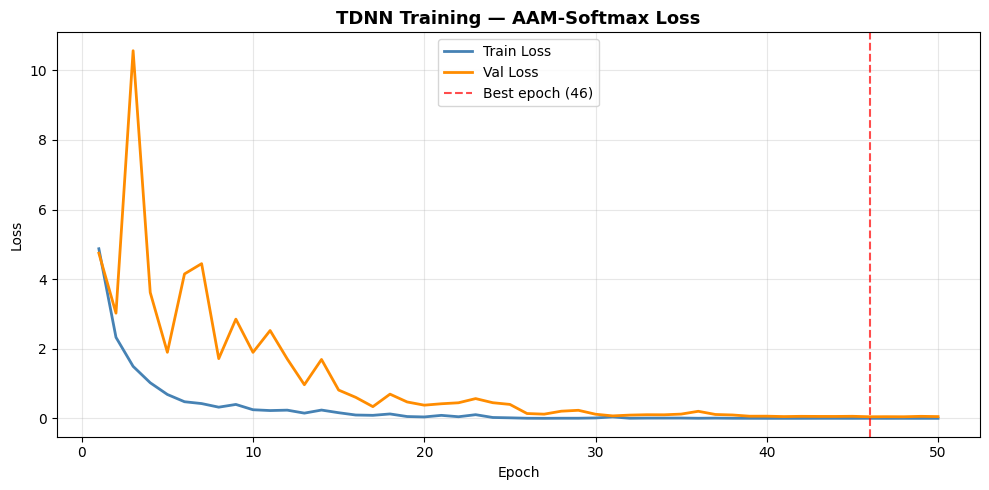

In [7]:
eps = range(1, EPOCHS+1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(eps, history['train'], label='Train Loss',  color='steelblue',  lw=2)
ax.plot(eps, history['val'],   label='Val Loss',    color='darkorange', lw=2)
ax.axvline(best_ep, color='red', ls='--', alpha=0.7, label=f'Best epoch ({best_ep})')
ax.set_title('TDNN Training — AAM-Softmax Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150)
plt.show()

## Step 5: Extract Embeddings

In [8]:
## Step 5: Extract Embeddings
model.load_state_dict(torch.load(f'{MODEL_DIR}/tdnn_best.pt', map_location=device))
model.eval()

@torch.no_grad()
def get_embedding(filepath):
    feat = extract_mfcc(filepath, max_frames=MAX_FRAMES)
    feat = torch.FloatTensor(feat).unsqueeze(0).to(device)
    return model(feat).cpu().numpy().flatten()

embeddings, labels_list = [], []
for rec in all_recs:
    if not os.path.exists(rec['filepath']): continue
    embeddings.append(get_embedding(rec['filepath']))
    labels_list.append(rec['label'])

embeddings = np.array(embeddings)
labels_arr = np.array(labels_list)

os.makedirs(f'{OUT_DIR}/data', exist_ok=True)
np.save(f'{OUT_DIR}/data/embeddings.npy',       embeddings)
np.save(f'{OUT_DIR}/data/embedding_labels.npy', labels_arr)

print(f'Embeddings shape : {embeddings.shape}')
print(f'Genuine  : {(labels_arr=="genuine").sum()}')
print(f'Impostor : {(labels_arr=="impostor").sum()}')


Embeddings shape : (800, 256)
Genuine  : 400
Impostor : 400


## Step 6: t-SNE Visualization

Running t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


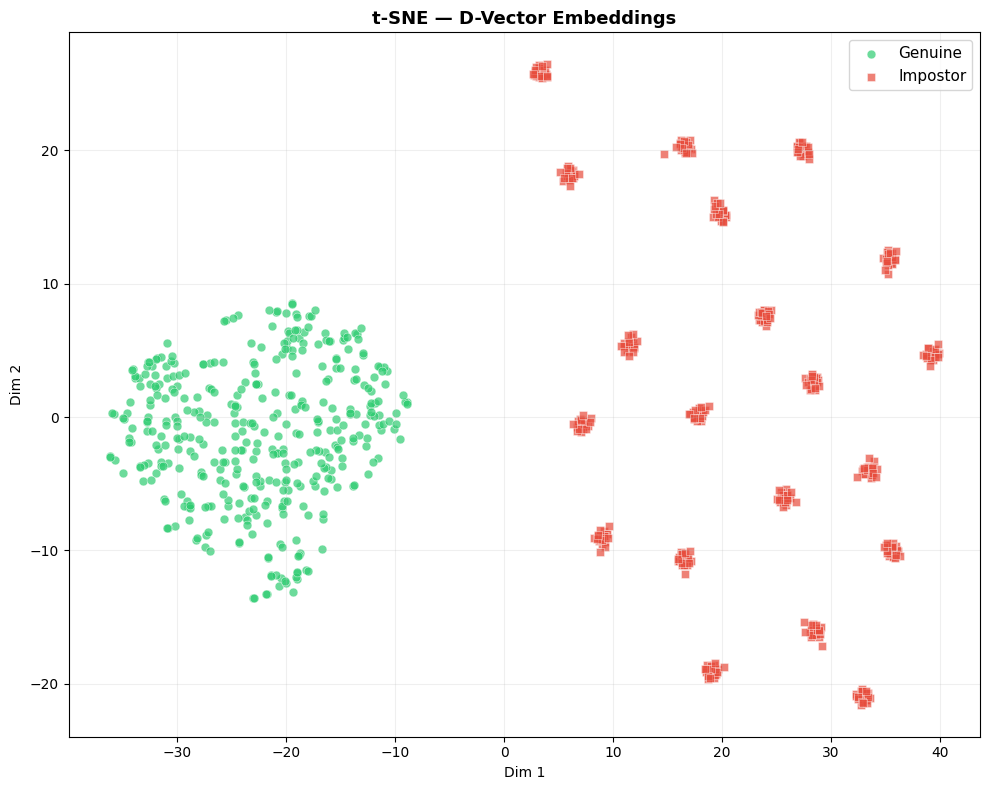

In [9]:
print('Running t-SNE...')
emb_2d = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000).fit_transform(embeddings)

colors  = {'genuine': '#2ecc71', 'impostor': '#e74c3c', 'spoof': '#3498db'}
markers = {'genuine': 'o',       'impostor': 's',       'spoof': '^'}
fig, ax = plt.subplots(figsize=(10, 8))
for lab in np.unique(labels_arr):
    mask = labels_arr == lab
    ax.scatter(emb_2d[mask,0], emb_2d[mask,1],
               c=colors.get(lab,'gray'), marker=markers.get(lab,'o'),
               label=lab.capitalize(), alpha=0.7, s=40,
               edgecolors='white', linewidths=0.4)
ax.set_title('t-SNE — D-Vector Embeddings', fontsize=13, fontweight='bold')
ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
ax.legend(fontsize=11); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/tsne.png', dpi=150)
plt.show()

## Step 7: Enrollment & Verification

In [10]:
# Step 8: Enrollment & Verification Scores
all_genuine    = glob.glob(f'{GENUINE_DIR}/*.wav')
impostor_files = glob.glob(f'{IMPOSTOR_DIR}/*.wav')
spoof_files    = glob.glob(f'{BASE_INPUT}/data/processed/spoof/*.wav')

# Split originals from augmented
original_genuine = [f for f in all_genuine if 'aug_' not in Path(f).stem]

print(f'Original genuine : {len(original_genuine)}')
print(f'Impostor files   : {len(impostor_files)}')
print(f'Spoof files      : {len(spoof_files)}')

# Enroll with first 50% of originals
mid           = len(original_genuine) // 2
enroll_files  = original_genuine[:mid]
test_genuine  = original_genuine[mid:]

enroll_embs   = np.array([get_embedding(f) for f in enroll_files])
speaker_model = enroll_embs.mean(axis=0)
speaker_model /= (np.linalg.norm(speaker_model) + 1e-8)
print(f'\nEnrolled with {len(enroll_embs)} files')

scores, true_labels, attack_types = [], [], []

for f in test_genuine:
    scores.append(1 - cosine(speaker_model, get_embedding(f)))
    true_labels.append(1)
    attack_types.append('genuine')

for f in impostor_files[:100]:
    scores.append(1 - cosine(speaker_model, get_embedding(f)))
    true_labels.append(0)
    attack_types.append('impostor')

for f in spoof_files[:100]:
    scores.append(1 - cosine(speaker_model, get_embedding(f)))
    true_labels.append(0)
    attack_types.append('spoof')

scores       = np.array(scores)
true_labels  = np.array(true_labels)
attack_types = np.array(attack_types)

print(f'\nTest pairs: {len(scores)}')
print(f'  Genuine  : {(attack_types=="genuine").sum()}')
print(f'  Impostor : {(attack_types=="impostor").sum()}')
print(f'  Spoof    : {(attack_types=="spoof").sum()}')
print('\nAverage similarity scores per type:')
for atype in ['genuine', 'impostor', 'spoof']:
    mask = attack_types == atype
    if mask.sum() > 0:
        print(f'  {atype:10s}: {scores[mask].mean():.4f} ± {scores[mask].std():.4f}')


Original genuine : 136
Impostor files   : 400
Spoof files      : 400

Enrolled with 68 files

Test pairs: 268
  Genuine  : 68
  Impostor : 100
  Spoof    : 100

Average similarity scores per type:
  genuine   : 0.9481 ± 0.0238
  impostor  : -0.3315 ± 0.1520
  spoof     : -0.2746 ± 0.4194


## Step 8: Metrics — EER, TAR@FAR, AUC

In [11]:
fpr, tpr, thresholds = roc_curve(true_labels, scores, pos_label=1)
fnr = 1 - tpr

def compute_eer(fpr, fnr):
    idx  = np.nanargmin(np.abs(fpr - fnr))
    eer  = (fpr[idx] + fnr[idx]) / 2 * 100
    return eer, thresholds[idx]

def tar_at_far(fpr, tpr, target):
    return float(interp1d(fpr, tpr)(target)) * 100

eer, eer_thresh = compute_eer(fpr, fnr)
tar_1           = tar_at_far(fpr, tpr, 0.01)
tar_01          = tar_at_far(fpr, tpr, 0.001)
auc             = roc_auc_score(true_labels, scores) * 100

print('=' * 45)
print('  TEXT-DEPENDENT TDNN — RESULTS')
print('=' * 45)
print(f'  EER              : {eer:.2f}%')
print(f'  EER Threshold    : {eer_thresh:.4f}')
print(f'  TAR @ FAR=1%     : {tar_1:.2f}%')
print(f'  TAR @ FAR=0.1%   : {tar_01:.2f}%')
print(f'  AUC              : {auc:.2f}%')
print('=' * 45)

  TEXT-DEPENDENT TDNN — RESULTS
  EER              : 0.00%
  EER Threshold    : 0.8732
  TAR @ FAR=1%     : 100.00%
  TAR @ FAR=0.1%   : 100.00%
  AUC              : 100.00%


## Step 9: Evaluation Plots

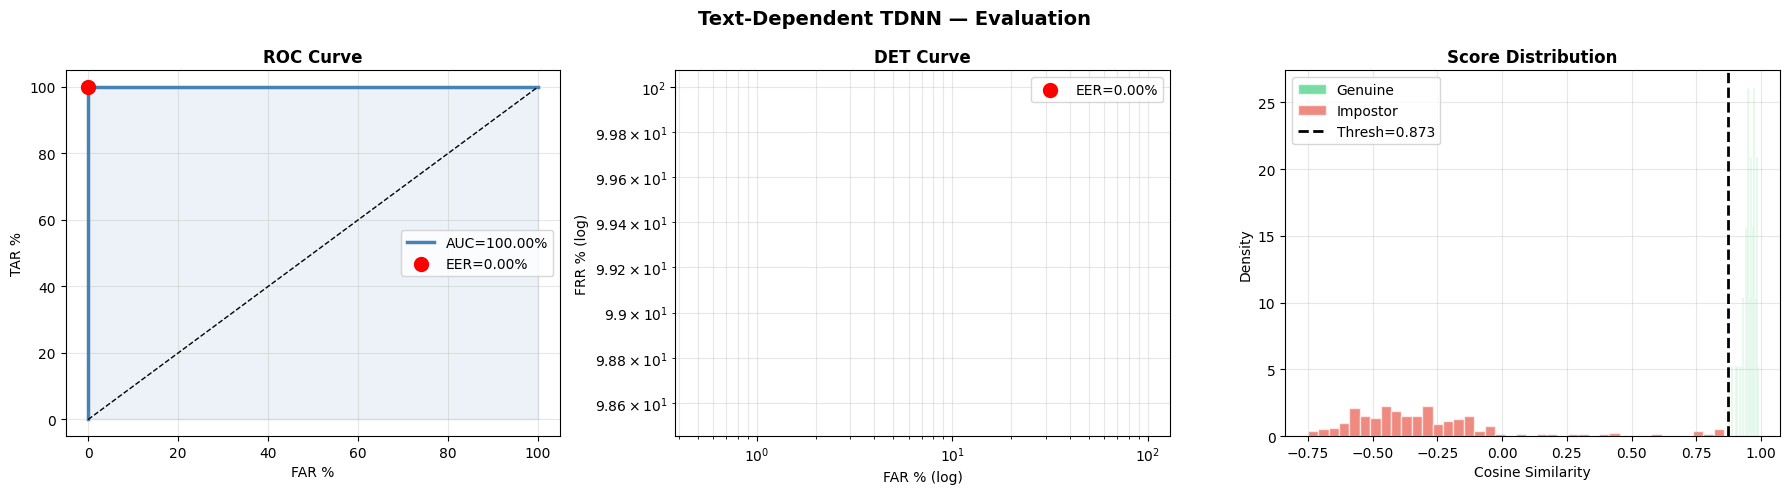

In [12]:
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3)

# ROC
ax1 = fig.add_subplot(gs[0])
ax1.plot(fpr*100, tpr*100, color='steelblue', lw=2.5, label=f'AUC={auc:.2f}%')
ax1.fill_between(fpr*100, tpr*100, alpha=0.1, color='steelblue')
ax1.plot([0,100],[0,100],'k--', lw=1)
ax1.scatter([eer],[100-eer], color='red', s=100, zorder=5, label=f'EER={eer:.2f}%')
ax1.set_title('ROC Curve', fontweight='bold')
ax1.set_xlabel('FAR %'); ax1.set_ylabel('TAR %')
ax1.legend(); ax1.grid(alpha=0.3)

# DET
ax2 = fig.add_subplot(gs[1])
ax2.plot(fpr*100, fnr*100, color='darkorange', lw=2.5)
ax2.scatter([eer],[eer], color='red', s=100, zorder=5, label=f'EER={eer:.2f}%')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_title('DET Curve', fontweight='bold')
ax2.set_xlabel('FAR % (log)'); ax2.set_ylabel('FRR % (log)')
ax2.legend(); ax2.grid(which='both', alpha=0.3)

# Score distribution
ax3 = fig.add_subplot(gs[2])
ax3.hist(scores[true_labels==1], bins=40, alpha=0.65, color='#2ecc71',
         label='Genuine',  density=True, edgecolor='white')
ax3.hist(scores[true_labels==0], bins=40, alpha=0.65, color='#e74c3c',
         label='Impostor', density=True, edgecolor='white')
ax3.axvline(eer_thresh, color='black', ls='--', lw=2, label=f'Thresh={eer_thresh:.3f}')
ax3.set_title('Score Distribution', fontweight='bold')
ax3.set_xlabel('Cosine Similarity'); ax3.set_ylabel('Density')
ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle('Text-Dependent TDNN — Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

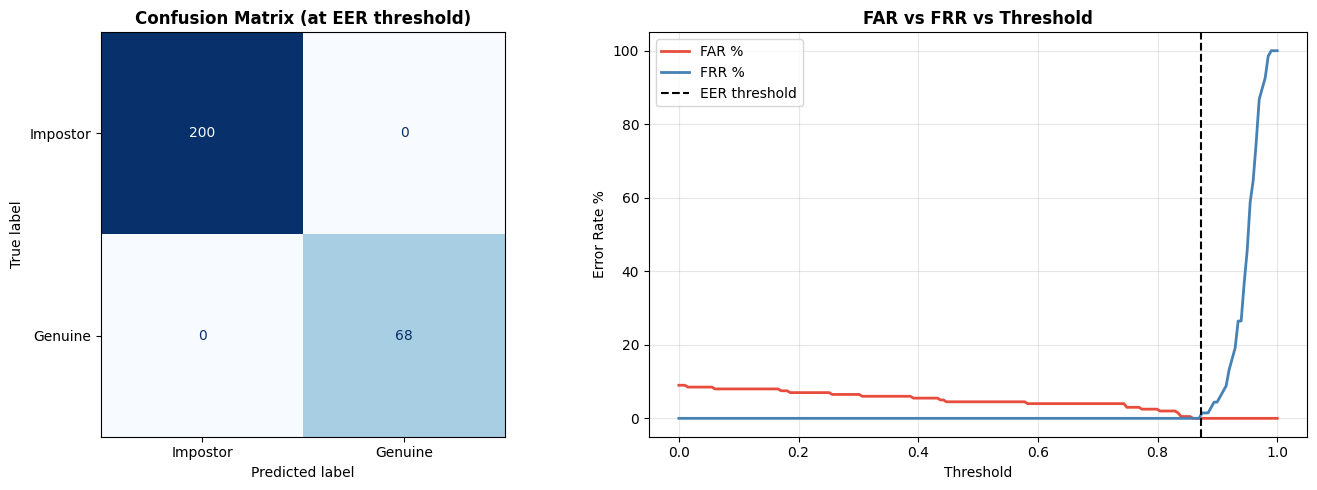

Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
F1        : 100.00%


In [13]:
# Confusion matrix + FAR/FRR vs threshold
pred = (scores >= eer_thresh).astype(int)
cm   = confusion_matrix(true_labels, pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=['Impostor','Genuine']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (at EER threshold)', fontweight='bold')

thresh_range = np.linspace(0, 1, 200)
far_l, frr_l = [], []
for t in thresh_range:
    p  = (scores >= t).astype(int)
    fp = ((p==1)&(true_labels==0)).sum()
    fn = ((p==0)&(true_labels==1)).sum()
    tn = ((p==0)&(true_labels==0)).sum()
    tp = ((p==1)&(true_labels==1)).sum()
    far_l.append(fp/(fp+tn+1e-8)*100)
    frr_l.append(fn/(fn+tp+1e-8)*100)

axes[1].plot(thresh_range, far_l, label='FAR %', color='#e74c3c', lw=2)
axes[1].plot(thresh_range, frr_l, label='FRR %', color='steelblue', lw=2)
axes[1].axvline(eer_thresh, color='black', ls='--', label=f'EER threshold')
axes[1].set_title('FAR vs FRR vs Threshold', fontweight='bold')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Error Rate %')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_threshold.png', dpi=150)
plt.show()

TP,FP,TN,FN = cm[1,1],cm[0,1],cm[0,0],cm[1,0]
print(f'Accuracy  : {(TP+TN)/(TP+TN+FP+FN)*100:.2f}%')
print(f'Precision : {TP/(TP+FP+1e-8)*100:.2f}%')
print(f'Recall    : {TP/(TP+FN+1e-8)*100:.2f}%')
print(f'F1        : {2*TP/(2*TP+FP+FN+1e-8)*100:.2f}%')

## Step 10: Save Results

In [14]:
# Step 12: Save Results
# Fallback values in case variables were lost
_emb_dim   = EMB_DIM   if 'EMB_DIM'   in dir() else 256
_epochs    = EPOCHS    if 'EPOCHS'    in dir() else 50
_best_val  = best_val  if 'best_val'  in dir() else 0.0
_best_ep   = best_ep   if 'best_ep'   in dir() else 0
_eer       = eer       if 'eer'       in dir() else 0.0
_eer_thresh= eer_thresh if 'eer_thresh' in dir() else 0.0
_tar_1     = tar_1     if 'tar_1'     in dir() else 0.0
_tar_01    = tar_01    if 'tar_01'    in dir() else 0.0
_auc       = auc       if 'auc'       in dir() else 0.0

results = {
    'model'            : 'TDNN + AAM-Softmax',
    'embedding_dim'    : _emb_dim,
    'epochs'           : _epochs,
    'best_val_loss'    : round(_best_val, 4),
    'best_epoch'       : _best_ep,
    'eer_pct'          : round(_eer, 2),
    'eer_threshold'    : round(float(_eer_thresh), 4),
    'tar_at_far_1pct'  : round(_tar_1, 2),
    'tar_at_far_01pct' : round(_tar_01, 2),
    'auc_pct'          : round(_auc, 2),
}
with open(f'{RESULTS_DIR}/phase2_results.json', 'w') as f:
    json.dump(results, f, indent=2)
with open(f'{MODEL_DIR}/enrollment.pkl', 'wb') as f:
    pickle.dump({'speaker_model': speaker_model, 'threshold': _eer_thresh}, f)

print('Phase 2 Complete!')
print('=' * 45)
for k, v in results.items():
    print(f'  {k:25s}: {v}')
print(f'\nModels  : {MODEL_DIR}')
print(f'Results : {RESULTS_DIR}')
print('\nNext: Phase 3 — Text-Independent (ECAPA-TDNN)')


Phase 2 Complete!
  model                    : TDNN + AAM-Softmax
  embedding_dim            : 256
  epochs                   : 50
  best_val_loss            : 0.0453
  best_epoch               : 46
  eer_pct                  : 0.0
  eer_threshold            : 0.8732
  tar_at_far_1pct          : 100.0
  tar_at_far_01pct         : 100.0
  auc_pct                  : 100.0

Models  : /kaggle/working/voice_auth_phase2/models
Results : /kaggle/working/voice_auth_phase2/results

Next: Phase 3 — Text-Independent (ECAPA-TDNN)
